# Importing Libraries and Datasets

In [1]:
# Install dependencies
# Usually error messages when importing libraries direct you to install the correct dependencies
# !pip install openpyxl # Needed for pandas to parse excel file. Modern library for .xlsx (Excel 2007+) files.
# !pip install nbimporter

In [2]:
# Import necessary library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta

# Custom libraries
import support_functions as sf

In [3]:
# Excel file path
excel_file_path = '../data/LifecycleDS-Exercise-sampledata.xlsx'

# Load each sheet into a separate DataFrame
df_onboarding = pd.read_excel(excel_file_path, sheet_name='team_onboarding_experiment')
df_prod_activity = pd.read_excel(excel_file_path, sheet_name='team_prod_activity_log')
df_financial = pd.read_excel(excel_file_path, sheet_name='team_financial_metrics')

# Shape check to count rows and columns
print("Onboarding data shape:", df_onboarding.shape)
print("Prod activity data shape:", df_prod_activity.shape)
print("Financial data shape:", df_financial.shape)

Onboarding data shape: (120, 5)
Prod activity data shape: (250, 5)
Financial data shape: (20, 4)


# Exploratory Analysis

In [4]:
df_onboarding.head()

,team_id,creator_user_id,creation_timestamp_utc,email_journey,date_first_plus_one_joiner_utc
0,T001,U1001,2023-09-01 10:00:00,Control,2023-09-04
1,T002,U1002,2023-09-01 10:05:00,Control,2023-09-08
2,T003,U1003,2023-09-01 10:10:00,Control,NaT
3,T004,U1004,2023-09-01 10:15:00,Control,2023-09-06
4,T005,U1005,2023-09-01 10:20:00,Control,NaT


In [5]:
df_prod_activity.head()

,activity_id,team_id,user_id,activity_timestamp_utc,feature_used
0,A001,T001,U1001,2023-09-01 10:02:00,Sent_Message
1,A002,T041,U1041,2023-09-04 13:25:00,Created_Channel
2,A003,T081,U1081,2023-09-07 16:45:00,Sent_Message
3,A004,T045,U1045,2023-09-05 10:30:00,Created_Canvas
4,A005,T002,U1002,2023-09-02 11:30:00,Used_Search


In [6]:
df_financial.head()

,team_id,conversion_timestamp_utc,conversion_type,first_annual_contract_value_usd
0,T004,2023-10-15 11:30:00,Monthly,1500
1,T019,2023-11-20 09:00:00,Annual,1500
2,T027,2023-10-05 14:00:00,Monthly,1500
3,T036,2023-11-10 16:00:00,Annual,1500
4,T041,2023-09-25 10:00:00,Annual,3000


# Understanding Categorical Variables 

In [170]:
# add dataframes to a dictionary
datasets = {
    "team_onboarding_experiment": df_onboarding,
    "team_prod_activity_log": df_prod_activity,
    "team_financial_metrics": df_financial
}

# Loop through each dataset and print unique categorical values
for name, df in datasets.items():
    print(f"\n=== Unique values for dataset: {name} ===")
    sf.print_unique_categorical(df)


=== Unique values for dataset: team_onboarding_experiment ===

Column 'team_id' has 120 unique values:
['T001' 'T002' 'T003' 'T004' 'T005' 'T006' 'T007' 'T008' 'T009' 'T010'
 'T011' 'T012' 'T013' 'T014' 'T015' 'T016' 'T017' 'T018' 'T019' 'T020'
 'T021' 'T022' 'T023' 'T024' 'T025' 'T026' 'T027' 'T028' 'T029' 'T030'
 'T031' 'T032' 'T033' 'T034' 'T035' 'T036' 'T037' 'T038' 'T039' 'T040'
 'T041' 'T042' 'T043' 'T044' 'T045' 'T046' 'T047' 'T048' 'T049' 'T050'
 'T051' 'T052' 'T053' 'T054' 'T055' 'T056' 'T057' 'T058' 'T059' 'T060'
 'T061' 'T062' 'T063' 'T064' 'T065' 'T066' 'T067' 'T068' 'T069' 'T070'
 'T071' 'T072' 'T073' 'T074' 'T075' 'T076' 'T077' 'T078' 'T079' 'T080'
 'T081' 'T082' 'T083' 'T084' 'T085' 'T086' 'T087' 'T088' 'T089' 'T090'
 'T091' 'T092' 'T093' 'T094' 'T095' 'T096' 'T097' 'T098' 'T099' 'T100'
 'T101' 'T102' 'T103' 'T104' 'T105' 'T106' 'T107' 'T108' 'T109' 'T110'
 'T111' 'T112' 'T113' 'T114' 'T115' 'T116' 'T117' 'T118' 'T119' 'T120']

Column 'creator_user_id' has 120 unique va

In [15]:
# add dataframes to a dictionary
datasets = {
    "team_onboarding_experiment": df_onboarding,
    "team_prod_activity_log": df_prod_activity,
    "team_financial_metrics": df_financial
}

# Loop through each dataset and print unique categorical values
for name, df in datasets.items():
    print(f"\n=== Unique values for dataset: {name} ===")
    sf.unique_categorical(df)


=== Unique values for dataset: team_onboarding_experiment ===

Column 'team_id' has 120 unique values:

Column 'creator_user_id' has 120 unique values:

Column 'email_journey' has 3 unique values:

=== Unique values for dataset: team_prod_activity_log ===

Column 'activity_id' has 250 unique values:

Column 'team_id' has 63 unique values:

Column 'user_id' has 63 unique values:

Column 'feature_used' has 4 unique values:

=== Unique values for dataset: team_financial_metrics ===

Column 'team_id' has 20 unique values:

Column 'conversion_type' has 2 unique values:


In [16]:
# Exclude ID columns
exclude = ['team_id', 'creator_user_id', 'activity_id', 'user_id']

for name, df in datasets.items():
    print(f"\n=== Unique counts for dataset: {name} ===")
    counts = sf.category_counts(df, exclude_cols=exclude)
    for col, count in counts.items():
        counts


=== Unique counts for dataset: team_onboarding_experiment ===

Column 'email_journey' counts:
email_journey
Control      40
Variant_A    40
Variant_B    40
Name: count, dtype: int64

=== Unique counts for dataset: team_prod_activity_log ===

Column 'feature_used' counts:
feature_used
Created_Canvas     97
Used_Search        96
Sent_Message       42
Created_Channel    15
Name: count, dtype: int64

=== Unique counts for dataset: team_financial_metrics ===

Column 'conversion_type' counts:
conversion_type
Annual     11
Monthly     9
Name: count, dtype: int64


In [17]:
for name, df in datasets.items():
    print(f"\n=== Missing data for dataset: {name} ===")
    print(df.isna().sum())


=== Missing data for dataset: team_onboarding_experiment ===
team_id                            0
creator_user_id                    0
creation_timestamp_utc             0
email_journey                      0
date_first_plus_one_joiner_utc    36
dtype: int64

=== Missing data for dataset: team_prod_activity_log ===
activity_id               0
team_id                   0
user_id                   0
activity_timestamp_utc    0
feature_used              0
dtype: int64

=== Missing data for dataset: team_financial_metrics ===
team_id                            0
conversion_timestamp_utc           0
conversion_type                    0
first_annual_contract_value_usd    0
dtype: int64


In [174]:
df_onboarding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   team_id                         120 non-null    object        
 1   creator_user_id                 120 non-null    object        
 2   creation_timestamp_utc          120 non-null    datetime64[ns]
 3   email_journey                   120 non-null    object        
 4   date_first_plus_one_joiner_utc  84 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(3)
memory usage: 4.8+ KB


In [175]:
df_prod_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   activity_id             250 non-null    object        
 1   team_id                 250 non-null    object        
 2   user_id                 250 non-null    object        
 3   activity_timestamp_utc  250 non-null    datetime64[ns]
 4   feature_used            250 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 9.9+ KB


In [34]:
# There are no teams with more than one unique user
df_prod_activity[df_prod_activity.groupby('team_id')['user_id'].transform('nunique') > 1]

,activity_id,team_id,user_id,activity_timestamp_utc,feature_used


In [37]:
# Another method to make sure there are no teams with more than one unique user
# Get team_ids with more than 1 unique user
teams_with_multiple_users = df_prod_activity.groupby('team_id')['user_id'].nunique()
valid_teams = teams_with_multiple_users[teams_with_multiple_users > 1].index

# Filter the original DataFrame
df_prod_activity[df_prod_activity['team_id'].isin(valid_teams)]

,activity_id,team_id,user_id,activity_timestamp_utc,feature_used


In [35]:
df_financial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   team_id                          20 non-null     object        
 1   conversion_timestamp_utc         20 non-null     datetime64[ns]
 2   conversion_type                  20 non-null     object        
 3   first_annual_contract_value_usd  20 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 772.0+ bytes


In [177]:
df_onboarding.describe()

,creation_timestamp_utc,date_first_plus_one_joiner_utc
count,120,84
mean,2023-09-06 02:57:29.999999744,2023-09-06 06:17:08.571428608
min,2023-09-01 10:00:00,2023-09-04 00:00:00
25%,2023-09-03 12:28:45,2023-09-05 00:00:00
50%,2023-09-06 02:57:30,2023-09-06 00:00:00
75%,2023-09-08 17:26:15,2023-09-08 00:00:00
max,2023-09-10 19:55:00,2023-09-10 00:00:00


In [178]:
df_prod_activity.describe()

,activity_timestamp_utc
count,250
mean,2023-09-22 19:28:40.080000
min,2023-09-01 10:02:00
25%,2023-09-20 16:07:30
50%,2023-09-24 03:30:00
75%,2023-09-27 14:45:00
max,2023-10-06 22:00:00


In [38]:
df_financial.describe()

,conversion_timestamp_utc,first_annual_contract_value_usd
count,20,20.000000
mean,2023-11-01 21:31:30,2725.000000
min,2023-09-25 10:00:00,1500.000000
25%,2023-10-14 04:37:30,2000.000000
50%,2023-11-03 14:30:00,2500.000000
75%,2023-11-21 18:30:00,4000.000000
max,2023-12-05 11:00:00,4000.000000
std,NaN,979.728749


In [39]:
# Clearly understand participant number in experiment
print(f"Teams in experiment: {len(df_onboarding)}")
print(f"Activity records: {len(df_prod_activity)}")
print(f"Converted teams: {len(df_financial)}")

Teams in experiment: 120
Activity records: 250
Converted teams: 20


# Number of Teams that invited it's first Team Member 

In [42]:
df_onboarding['date_first_plus_one_joiner_utc'].isna().value_counts()

date_first_plus_one_joiner_utc
False    84
True     36
Name: count, dtype: int64

C:\Users\John\AppData\Local\Temp\ipykernel_22136\1605476549.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette=['red', 'green'])


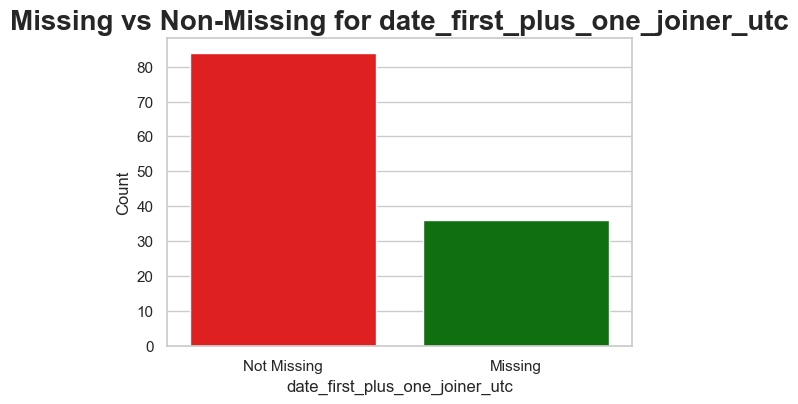

In [181]:
# Count missing vs non-missing
missing_counts = df_onboarding['date_first_plus_one_joiner_utc'].isna().value_counts().rename(index={True: 'Missing', False: 'Not Missing'})

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette=['red', 'green'])
plt.title("Missing vs Non-Missing for date_first_plus_one_joiner_utc", fontsize=20, fontweight='bold')
plt.ylabel("Count")
plt.show()

C:\Users\John\AppData\Local\Temp\ipykernel_22136\2172097404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_by_journey.index, y=missing_by_journey.values, palette='Reds_r')


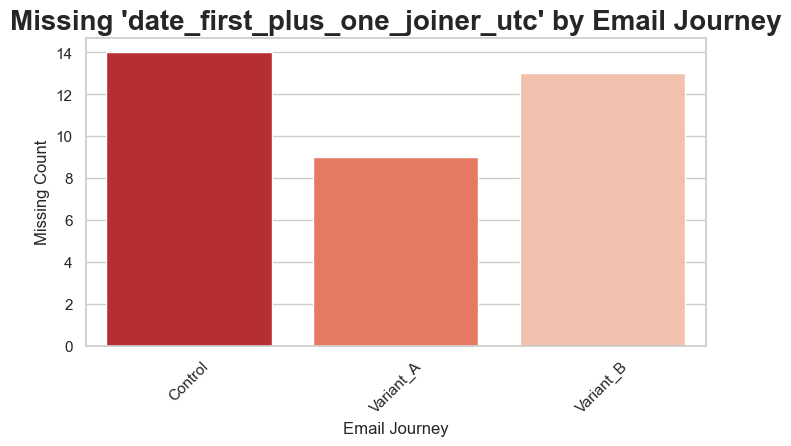

In [182]:
missing_by_journey = df_onboarding.groupby('email_journey')['date_first_plus_one_joiner_utc'].apply(lambda x: x.isna().sum())

plt.figure(figsize=(8,4))
sns.barplot(x=missing_by_journey.index, y=missing_by_journey.values, palette='Reds_r')
plt.title("Missing 'date_first_plus_one_joiner_utc' by Email Journey", fontsize=20, fontweight='bold')
plt.ylabel("Missing Count")
plt.xlabel("Email Journey")
plt.xticks(rotation=45)
plt.show()

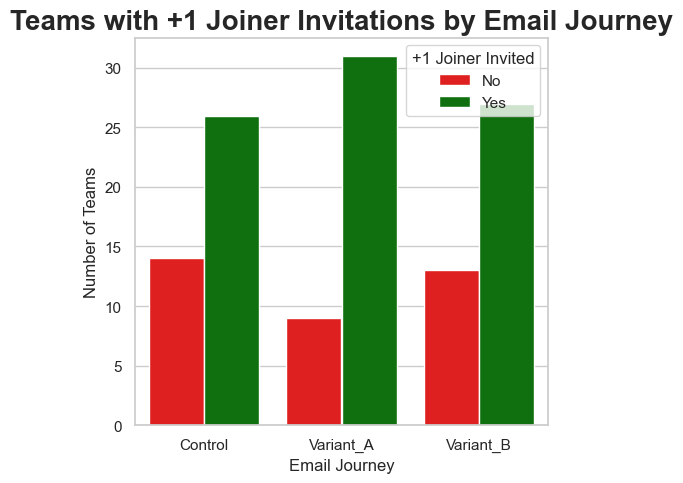

In [52]:
# Create a column indicating +1 invitation status
df_onboarding['plus_one_invited'] = df_onboarding['date_first_plus_one_joiner_utc'].notna().map({True: 'Yes', False: 'No'})

# Count number of teams per email_journey and invitation status
counts = df_onboarding.groupby(['email_journey', 'plus_one_invited']).size().reset_index(name='count')

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(5,5))
sns.barplot(data=counts, x='email_journey', y='count', hue='plus_one_invited', palette=['red','green'])
plt.title("Teams with +1 Joiner Invitations by Email Journey",  fontsize=20, fontweight='bold')
plt.ylabel("Number of Teams")
plt.xlabel("Email Journey")
plt.xticks()
plt.legend(title='+1 Joiner Invited')
plt.tight_layout()
plt.show()

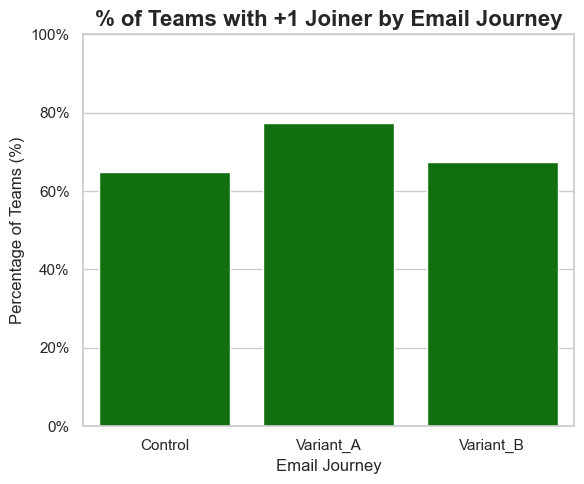

In [58]:
# Create indicator
df_onboarding['plus_one_invited'] = df_onboarding['date_first_plus_one_joiner_utc'].notna()

# Compute percentage
percentages = (
    df_onboarding.groupby('email_journey')['plus_one_invited'].mean().reset_index(name='pct_plus_one')
)

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(6,5))
sns.barplot(data=percentages, x='email_journey', y='pct_plus_one', color='green')
plt.title("% of Teams with +1 Joiner by Email Journey", fontsize=16, fontweight='bold')
plt.ylabel("Percentage of Teams (%)")
plt.xlabel("Email Journey")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
plt.tight_layout()
plt.show()

# Analysis of Days to Plus One Joiner Primary Metric

### Conclusion - Can't use this metric due to data quality issue

In [59]:
# Days to +1 Joiner
df_onboarding['days_to_plus_one'] = (df_onboarding['date_first_plus_one_joiner_utc'] - df_onboarding['creation_timestamp_utc']).dt.days

speed_metrics = df_onboarding.groupby('email_journey')['days_to_plus_one'].agg(['median','mean']).rename(columns = {'median':'days_to_plus_one_median', 'mean':'days_to_plus_one_mean'}).reset_index()
print(speed_metrics)

  email_journey  days_to_plus_one_median  days_to_plus_one_mean
0       Control                      3.0               3.269231
1     Variant_A                     -2.0              -1.516129
2     Variant_B                     -2.0              -2.185185


In [81]:
df_onboarding

,team_id,creator_user_id,creation_timestamp_utc,email_journey,date_first_plus_one_joiner_utc,plus_one_invited,days_to_plus_one,converted,plus_one_status
0,T001,U1001,2023-09-01 10:00:00,Control,2023-09-04,"Yes, +1 invited",2.0,False,True
1,T002,U1002,2023-09-01 10:05:00,Control,2023-09-08,"Yes, +1 invited",6.0,False,True
2,T003,U1003,2023-09-01 10:10:00,Control,NaT,No +1 invited,NaN,False,False
3,T004,U1004,2023-09-01 10:15:00,Control,2023-09-06,"Yes, +1 invited",4.0,True,True
4,T005,U1005,2023-09-01 10:20:00,Control,NaT,No +1 invited,NaN,False,False
...,...,...,...,...,...,...,...,...,...
115,T116,U1116,2023-09-10 19:35:00,Variant_B,2023-09-09,"Yes, +1 invited",-2.0,False,True
116,T117,U1117,2023-09-10 19:40:00,Variant_B,2023-09-06,"Yes, +1 invited",-5.0,True,True
117,T118,U1118,2023-09-10 19:45:00,Variant_B,NaT,No +1 invited,NaN,False,False
118,T119,U1119,2023-09-10 19:50:00,Variant_B,2023-09-07,"Yes, +1 invited",-4.0,False,True


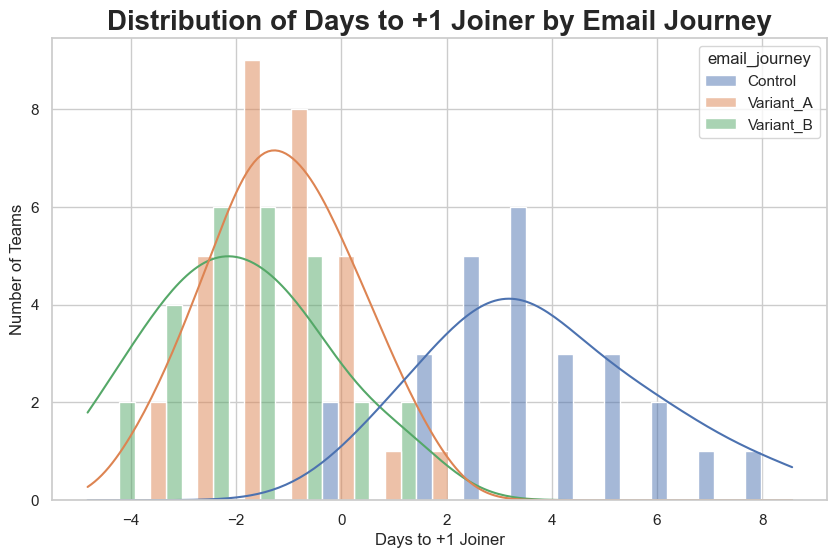

In [120]:
df_plot = df_onboarding.dropna(subset=['days_to_plus_one'])

# Plot distribution
plt.figure(figsize=(10,6))
sns.histplot(
    data=df_plot,
    x='days_to_plus_one',
    hue='email_journey',
    multiple='dodge', 
    bins=15,
    kde=True
)
plt.title('Distribution of Days to +1 Joiner by Email Journey',  fontsize=20, fontweight='bold')
plt.xlabel('Days to +1 Joiner')
plt.ylabel('Number of Teams')
plt.show()

In [186]:
df_onboarding

,team_id,creator_user_id,creation_timestamp_utc,email_journey,date_first_plus_one_joiner_utc,plus_one_invited,days_to_plus_one
0,T001,U1001,2023-09-01 10:00:00,Control,2023-09-04,True,2.0
1,T002,U1002,2023-09-01 10:05:00,Control,2023-09-08,True,6.0
2,T003,U1003,2023-09-01 10:10:00,Control,NaT,False,NaN
3,T004,U1004,2023-09-01 10:15:00,Control,2023-09-06,True,4.0
4,T005,U1005,2023-09-01 10:20:00,Control,NaT,False,NaN
...,...,...,...,...,...,...,...
115,T116,U1116,2023-09-10 19:35:00,Variant_B,2023-09-09,True,-2.0
116,T117,U1117,2023-09-10 19:40:00,Variant_B,2023-09-06,True,-5.0
117,T118,U1118,2023-09-10 19:45:00,Variant_B,NaT,False,NaN
118,T119,U1119,2023-09-10 19:50:00,Variant_B,2023-09-07,True,-4.0


# Mean of days_to_plus_one by Variant

In [60]:
df_onboarding.groupby('email_journey')['days_to_plus_one'].mean()

email_journey
Control      3.269231
Variant_A   -1.516129
Variant_B   -2.185185
Name: days_to_plus_one, dtype: float64

# OVERALL CONCULSION:
## Do not use Days to Plus One as a Metric
## We will use Proportion of Teams with a Plus One Joiner